<a href="https://colab.research.google.com/github/DapedGuardiola/NextWatch-projects/blob/main/sistem_rekomendasi_film_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Sistem Rekomendasi Film — PBL Final Project
## Pemodelan: Forward Chaining | Backward Chaining | Teorema Bayes | Certainty Factor

**Dataset:** IMDB Top 1000 Movies  
**Fitur:** `title`, `release_year`, `genres`, `imdb_rating`, `star1`, `star2`, `star3`, `star4`  
**Tujuan:** Membangun dan membandingkan empat metode inferensi untuk sistem rekomendasi film.

---

## 📋 Daftar Isi
1. Import Library & Setup
2. Load Dataset
3. Preprocessing (Cleaning → Transformasi → Seleksi Fitur)
4. User Persona (Simulasi Data Survei)
5. Model A — Forward Chaining
6. Model B — Backward Chaining
7. Model C — Teorema Bayes (Fitur ForYou)
8. Model D — Certainty Factor
9. Perbandingan & Analisis Semua Model
10. Justifikasi Pemilihan Model Terbaik

---
## 1. Import Library & Setup

In [ ]:
import pandas as pd
import numpy as np
import warnings
import io
import math
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
print('✅ Semua library berhasil diimport.')

✅ Semua library berhasil diimport.


---
## 2. Load Dataset

**Pilih salah satu opsi di bawah untuk memuat dataset.**

- **Opsi 1 (termudah):** Upload file langsung via dialog Colab
- **Opsi 2:** Mount Google Drive
- **Opsi 3:** Download dari Kaggle

In [ ]:
from google.colab import files
print('Silakan upload file imdb_top_1000.csv ...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded['imdb_top_1000.csv']))

print(f'Shape awal  : {df_raw.shape}')
print(f'Kolom       : {df_raw.columns.tolist()}')
df_raw.head(3)

Silakan upload file imdb_top_1000.csv ...


Saving imdb_top_1000.csv to imdb_top_1000.csv
Shape awal  : (1000, 16)
Kolom       : ['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYTc0MGEtZmNh...,The Shawshank Redemption,1994,A,142 min,Drama,9.3000,"Two imprisoned men bond over a number of years, finding ...",80.0000,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNjYxNmUtYTAw...,The Godfather,1972,A,175 min,"Crime, Drama",9.2000,An organized crime dynasty's aging patriarch transfers c...,100.0000,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNTMwODM0NF5B...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0000,When the menace known as the Joker wreaks havoc and chao...,84.0000,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


---
## 3. Preprocessing
### 3.1 Seleksi Fitur

In [ ]:
FEATURES = ['Series_Title', 'Released_Year', 'Genre', 'IMDB_Rating',
            'Star1', 'Star2', 'Star3', 'Star4']

df = df_raw[FEATURES].copy()
df.columns = ['title', 'release_year', 'genres', 'imdb_rating',
              'star1', 'star2', 'star3', 'star4']

print('Fitur yang dipilih:', df.columns.tolist())
print(f'Jumlah baris      : {len(df)}')
df.head()

Fitur yang dipilih: ['title', 'release_year', 'genres', 'imdb_rating', 'star1', 'star2', 'star3', 'star4']
Jumlah baris      : 1000


,title,release_year,genres,imdb_rating,star1,star2,star3,star4
0,The Shawshank Redemption,1994,Drama,9.3000,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,The Godfather,1972,"Crime, Drama",9.2000,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,The Dark Knight,2008,"Action, Crime, Drama",9.0000,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,The Godfather: Part II,1974,"Crime, Drama",9.0000,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,12 Angry Men,1957,"Crime, Drama",9.0000,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler


### 3.2 Cleaning — Missing Values & Duplikat

In [ ]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplikat ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

df.drop_duplicates(inplace=True)
df.dropna(subset=['title', 'genres', 'imdb_rating'], inplace=True)
for col in ['star1', 'star2', 'star3', 'star4']:
    df[col].fillna('', inplace=True)

print(f'Shape setelah cleaning: {df.shape}')

=== Missing Values ===
title           0
release_year    0
genres          0
imdb_rating     0
star1           0
star2           0
star3           0
star4           0
dtype: int64

=== Duplikat ===
Jumlah baris duplikat: 0
Shape setelah cleaning: (1000, 8)


### 3.3 Transformasi Data

In [ ]:
# 1. release_year → integer
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
df['release_year'].fillna(int(df['release_year'].median()), inplace=True)
df['release_year'] = df['release_year'].astype(int)

# 2. imdb_rating → float
df['imdb_rating'] = pd.to_numeric(df['imdb_rating'], errors='coerce')
df.dropna(subset=['imdb_rating'], inplace=True)

# 3. genres_list → list dari string genre
df['genres_list'] = df['genres'].apply(lambda x: [g.strip() for g in str(x).split(',')])

# 4. era rilis
def assign_era(y):
    if y < 1980:   return 'Classic'
    elif y < 2000: return 'Retro'
    elif y < 2010: return '2000s'
    elif y < 2020: return '2010s'
    else:          return 'Recent'
df['era'] = df['release_year'].apply(assign_era)

# 5. rating_class
def rating_class(r):
    if r >= 8.5:   return 'Masterpiece'
    elif r >= 8.0: return 'Excellent'
    elif r >= 7.5: return 'Good'
    else:          return 'Average'
df['rating_class'] = df['imdb_rating'].apply(rating_class)

# 6. all_stars → gabungan 4 aktor dalam list
df['all_stars'] = df.apply(
    lambda r: [s for s in [r['star1'], r['star2'], r['star3'], r['star4']] if s != ''],
    axis=1
)

# 7. Normalisasi nama
for col in ['star1', 'star2', 'star3', 'star4']:
    df[col] = df[col].str.strip()
df['title_clean'] = df['title'].str.strip().str.lower()

print('Transformasi selesai.')
df[['title', 'release_year', 'genres_list', 'imdb_rating', 'rating_class', 'era', 'all_stars']].head()

Transformasi selesai.


,title,release_year,genres_list,imdb_rating,rating_class,era,all_stars
0,The Shawshank Redemption,1994,[Drama],9.3000,Masterpiece,Retro,"[Tim Robbins, Morgan Freeman, Bob Gunton, William Sadler]"
1,The Godfather,1972,"[Crime, Drama]",9.2000,Masterpiece,Classic,"[Marlon Brando, Al Pacino, James Caan, Diane Keaton]"
2,The Dark Knight,2008,"[Action, Crime, Drama]",9.0000,Masterpiece,2000s,"[Christian Bale, Heath Ledger, Aaron Eckhart, Michael Ca..."
3,The Godfather: Part II,1974,"[Crime, Drama]",9.0000,Masterpiece,Classic,"[Al Pacino, Robert De Niro, Robert Duvall, Diane Keaton]"
4,12 Angry Men,1957,"[Crime, Drama]",9.0000,Masterpiece,Classic,"[Henry Fonda, Lee J. Cobb, Martin Balsam, John Fiedler]"


### 3.4 Statistik Deskriptif & Visualisasi

       release_year  imdb_rating
count     1000.0000    1000.0000
mean      1991.2250       7.9493
std         23.2867       0.2755
min       1920.0000       7.6000
25%       1976.0000       7.7000
50%       1999.0000       7.9000
75%       2009.0000       8.1000
max       2020.0000       9.3000


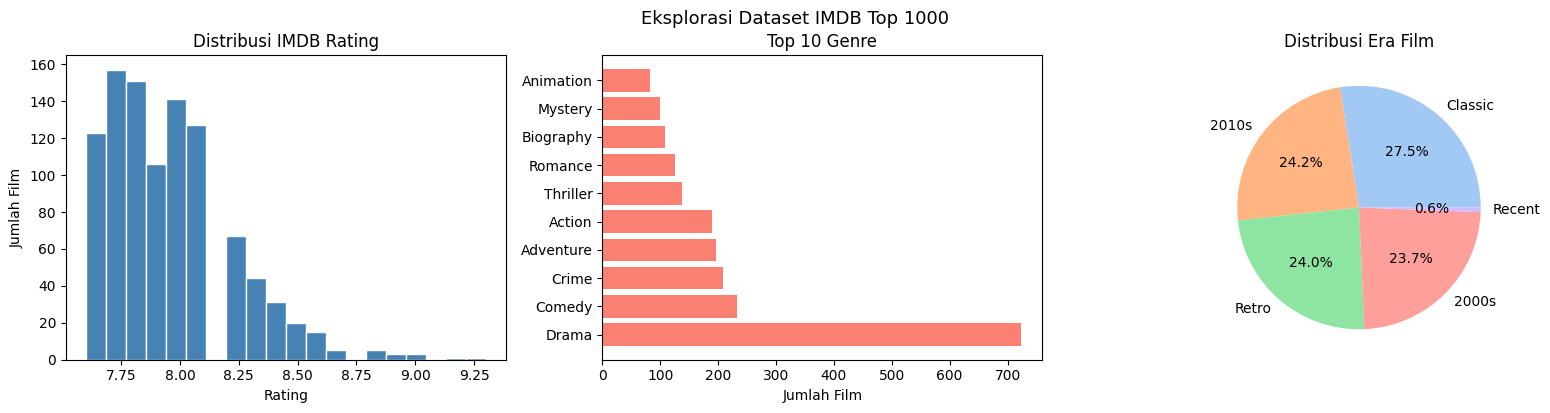

Dataset final: 1000 film, 13 kolom


In [ ]:
print(df[['release_year', 'imdb_rating']].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribusi rating
axes[0].hist(df['imdb_rating'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi IMDB Rating')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Jumlah Film')

# Top 10 genre
all_genres = [g for sub in df['genres_list'] for g in sub]
genre_counts = pd.Series(all_genres).value_counts().head(10)
axes[1].barh(genre_counts.index, genre_counts.values, color='salmon')
axes[1].set_title('Top 10 Genre'); axes[1].set_xlabel('Jumlah Film')

# Era
era_counts = df['era'].value_counts()
axes[2].pie(era_counts.values, labels=era_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'))
axes[2].set_title('Distribusi Era Film')

plt.tight_layout()
plt.suptitle('Eksplorasi Dataset IMDB Top 1000', fontsize=13, y=1.02)
plt.show()
print(f'Dataset final: {df.shape[0]} film, {df.shape[1]} kolom')

---
## 4. User Persona — Simulasi Data Preferensi Pengguna

Berdasarkan skema database:
- `user_profiles` — profil pengguna
- `user_preferences` — genre/aktor/film favorit (input awal Teorema Bayes / ForYou)
- `user_favorites` — film yang ditandai favorit (prior probability Bayes)

In [ ]:
user_profiles = pd.DataFrame({
    'user_id':    1,
    'nama':       'Audric',
    'usia':       21,
    'min_rating': 8.0,
}, index=[0])

user_preferences = {
    1: {'favorite_genres': ['Action', 'Comedy', 'Thriller'],
        'favorite_actors': ['Tom Holland', 'Robert Downey Jr.'],
        'favorite_films':  ['Avengers: Endgame', 'Spider-Man: No Way Home']}
}

user_favorites = {
    1: df[df['genres'].str.contains('Action', na=False)]['title'].head(5).tolist(),
}

print('=== user_profiles ===')
print(user_profiles.to_string(index=False))
print('\n=== user_preferences (User 1) ===')
for k, v in user_preferences[1].items():
    print(f'  {k}: {v}')
print('\n=== user_favorites (User 1) ===')
print(user_favorites[1])

=== user_profiles ===
 user_id   nama  usia  min_rating
       1 Audric    21      8.0000

=== user_preferences (User 1) ===
  favorite_genres: ['Action', 'Comedy', 'Thriller']
  favorite_actors: ['Tom Holland', 'Robert Downey Jr.']
  favorite_films: ['Avengers: Endgame', 'Spider-Man: No Way Home']

=== user_favorites (User 1) ===
['The Dark Knight', 'The Lord of the Rings: The Return of the King', 'Inception', 'The Lord of the Rings: The Fellowship of the Ring', 'The Lord of the Rings: The Two Towers']


---
## 5. Model A — Forward Chaining

### Konsep Teori
**Forward Chaining** (data-driven reasoning) dimulai dari *fakta yang diketahui* dan menerapkan rules secara berurutan untuk menarik kesimpulan.

- **Fakta awal**: genre favorit, rating minimum, preferensi aktor
- **Rules**: kondisi bertahap yang memfilter dan memberi skor kandidat
- **Alur**: Fakta → R1 (rating filter) → R2 (genre score) → R3 (actor score) → R4 (bonus) → R5 (threshold) → Rekomendasi

In [ ]:
class ForwardChainingRecommender:
    def __init__(self, dataset):
        self.df = dataset.copy()
        self.rules_fired = []

    def recommend(self, user_id, preferences, profile, top_n=5):
        self.rules_fired = []
        candidates = self.df.copy()
        candidates['fc_score'] = 0.0

        # R1: filter rating minimum
        min_r = profile.get('min_rating', 8.0)
        mask = candidates['imdb_rating'] >= min_r
        candidates = candidates[mask]
        self.rules_fired.append(f'R1: imdb_rating >= {min_r} => {mask.sum()} film lolos')

        # R2: genre match => +2 per genre cocok
        fav_g = [g.lower() for g in preferences.get('favorite_genres', [])]
        candidates['genre_match'] = candidates['genres_list'].apply(
            lambda gl: sum(1 for g in gl if g.lower() in fav_g))
        candidates['fc_score'] += candidates['genre_match'] * 2
        self.rules_fired.append(f'R2: genre match {fav_g} => {(candidates.genre_match>0).sum()} film')

        # R3: actor match => +3 per aktor cocok
        fav_a = [a.lower() for a in preferences.get('favorite_actors', [])]
        candidates['actor_match'] = candidates['all_stars'].apply(
            lambda sl: sum(1 for s in sl if s.lower() in fav_a))
        candidates['fc_score'] += candidates['actor_match'] * 3
        self.rules_fired.append(f'R3: actor match => {(candidates.actor_match>0).sum()} film')

        # R4: bonus +1 jika rating >= 8.5
        top_mask = candidates['imdb_rating'] >= 8.5
        candidates.loc[top_mask, 'fc_score'] += 1
        self.rules_fired.append(f'R4: bonus rating>=8.5 => {top_mask.sum()} film')

        # R5: hanya skor > 0
        candidates = candidates[candidates['fc_score'] > 0]
        self.rules_fired.append(f'R5: fc_score > 0 => {len(candidates)} kandidat tersisa')

        return candidates.sort_values(['fc_score', 'imdb_rating'], ascending=False).head(top_n)[
            ['title', 'genres', 'imdb_rating', 'release_year', 'star1', 'fc_score', 'genre_match', 'actor_match']]


fc_model = ForwardChainingRecommender(df)
uid = 1
fc_result = fc_model.recommend(uid, user_preferences[uid],
    {'min_rating': user_profiles[user_profiles.user_id==uid]['min_rating'].values[0]}, 5)

print('=== Forward Chaining — Rekomendasi User 1 ===')
print('Log Rules:')
for r in fc_model.rules_fired: print(' ', r)
print('\nHasil:')
print(fc_result.to_string(index=False))

=== Forward Chaining — Rekomendasi User 1 ===
Log Rules:
  R1: imdb_rating >= 8.0 => 463 film lolos
  R2: genre match ['action', 'comedy', 'thriller'] => 206 film
  R3: actor match => 3 film
  R4: bonus rating>=8.5 => 53 film
  R5: fc_score > 0 => 235 kandidat tersisa

Hasil:
                 title                    genres  imdb_rating  release_year             star1  fc_score  genre_match  actor_match
          Gisaengchung   Comedy, Drama, Thriller       8.6000          2019      Kang-ho Song    5.0000            2            0
     Avengers: Endgame  Action, Adventure, Drama       8.4000          2019         Joe Russo    5.0000            1            1
Avengers: Infinity War Action, Adventure, Sci-Fi       8.4000          2018         Joe Russo    5.0000            1            1
          The Avengers Action, Adventure, Sci-Fi       8.0000          2012 Robert Downey Jr.    5.0000            1            1
    Gangs of Wasseypur     Action, Comedy, Crime       8.2000          20

---
## 6. Model B — Backward Chaining

### Konsep Teori
**Backward Chaining** (goal-driven reasoning) dimulai dari *goal* dan bekerja mundur membuktikan sub-goal yang dibutuhkan.

- **Goal**: Film cocok untuk pengguna
- **Sub-goal**: rating OK AND (genre OK OR aktor OK)
- Sistem menelusuri kondisi secara rekursif top-down

In [ ]:
class BackwardChainingRecommender:
    def __init__(self, dataset):
        self.df = dataset.copy()
        self.proof_tree = {}

    def _sg_rating(self, row, min_r):   return row['imdb_rating'] >= min_r
    def _sg_genre(self, row, fav_g):    return any(g.lower() in [f.lower() for f in fav_g] for g in row['genres_list'])
    def _sg_actor(self, row, fav_a):    return any(s.lower() in [a.lower() for a in fav_a] for s in row['all_stars'])

    def _prove(self, row, preferences, profile):
        ev = {}
        ev['rating_ok'] = self._sg_rating(row, profile.get('min_rating', 7.0))
        if not ev['rating_ok']:
            return False, ev
        ev['genre_ok'] = self._sg_genre(row, preferences.get('favorite_genres', []))
        ev['actor_ok'] = self._sg_actor(row, preferences.get('favorite_actors', []))
        suitable = ev['rating_ok'] and (ev['genre_ok'] or ev['actor_ok'])
        return suitable, ev

    def recommend(self, user_id, preferences, profile, top_n=5):
        results = []
        self.proof_tree = {}
        for _, row in self.df.iterrows():
            ok, ev = self._prove(row, preferences, profile)
            if ok:
                score = (row['imdb_rating'] - 7.0) + int(ev['genre_ok'])*2 + int(ev['actor_ok'])*3
                results.append({'title': row['title'], 'genres': row['genres'],
                    'imdb_rating': row['imdb_rating'], 'release_year': row['release_year'],
                    'star1': row['star1'], 'bc_score': round(score, 3),
                    'genre_ok': ev['genre_ok'], 'actor_ok': ev['actor_ok']})
                self.proof_tree[row['title']] = ev
        if not results:
            return pd.DataFrame()
        return pd.DataFrame(results).sort_values('bc_score', ascending=False).head(top_n)


bc_model = BackwardChainingRecommender(df)
uid = 1
bc_result = bc_model.recommend(uid, user_preferences[uid], {'min_rating': 7.0}, 5)

print('=== Backward Chaining — Rekomendasi User 1 ===')
print('Sample Proof Tree (3 film):')
for t, ev in list(bc_model.proof_tree.items())[:3]: print(f'  [{t}] => {ev}')
print('\nHasil:')
print(bc_result.to_string(index=False))

=== Backward Chaining — Rekomendasi User 1 ===
Sample Proof Tree (3 film):
  [The Dark Knight] => {'rating_ok': True, 'genre_ok': True, 'actor_ok': False}
  [The Lord of the Rings: The Return of the King] => {'rating_ok': True, 'genre_ok': True, 'actor_ok': False}
  [Inception] => {'rating_ok': True, 'genre_ok': True, 'actor_ok': False}

Hasil:
                     title                    genres  imdb_rating  release_year             star1  bc_score  genre_ok  actor_ok
         Avengers: Endgame  Action, Adventure, Drama       8.4000          2019         Joe Russo    6.4000      True      True
    Avengers: Infinity War Action, Adventure, Sci-Fi       8.4000          2018         Joe Russo    6.4000      True      True
              The Avengers Action, Adventure, Sci-Fi       8.0000          2012 Robert Downey Jr.    6.0000      True      True
                  Iron Man Action, Adventure, Sci-Fi       7.9000          2008 Robert Downey Jr.    5.9000      True      True
Captain Ameri

---
## 7. Model C — Teorema Bayes (Fitur ForYou)

### Konsep Teori
$$P(H|E) = \\frac{P(E|H) \\cdot P(H)}{P(E)}$$

- **P(H)** = Prior: frekuensi genre dalam `user_favorites`
- **P(E|H)** = Likelihood: P(rating tinggi | genre)
- **P(H|E)** = Posterior: probabilitas film cocok

Laplace smoothing diterapkan untuk menghindari zero probability.

In [ ]:
class NaiveBayesForYou:
    def __init__(self, dataset):
        self.df = dataset.copy()
        self.prior = {}
        self.likelihood = {}

    def fit(self, user_id, favorites):
        fav_df = self.df[self.df['title'].isin(favorites)]
        if fav_df.empty:
            fav_df = self.df.head(20)

        genre_counts = defaultdict(int)
        total = 0
        for gl in fav_df['genres_list']:
            for g in gl:
                genre_counts[g] += 1; total += 1

        all_genres = list(set(g for gl in self.df['genres_list'] for g in gl))
        V = len(all_genres)
        self.prior = {g: (genre_counts.get(g, 0)+1)/(total+V) for g in all_genres}

        for genre in all_genres:
            gf = self.df[self.df['genres_list'].apply(lambda gl: genre in gl)]
            if len(gf) == 0:
                self.likelihood[genre] = 0.5
            else:
                self.likelihood[genre] = ((gf['imdb_rating'] >= 8.0).sum()+1) / (len(gf)+2)

        print(f'Model Bayes fitted. Top 5 prior genre:')
        for g, p in sorted(self.prior.items(), key=lambda x: -x[1])[:5]:
            print(f'   P({g}) = {p:.4f}')

    def score(self, row, fav_genres):
        log_p = sum(
            math.log(self.prior.get(g, 1e-9)) + math.log(self.likelihood.get(g, 0.5))
            for g in row['genres_list']
        )
        bonus = sum(1 for g in row['genres_list'] if g in fav_genres) * 0.5
        return log_p + bonus

    def recommend(self, user_id, preferences, favorites, top_n=5):
        self.fit(user_id, favorites)
        fav_g = preferences.get('favorite_genres', [])
        cands = self.df.copy()
        cands['bayes_score'] = cands.apply(lambda r: self.score(r, fav_g), axis=1)
        return cands.sort_values('bayes_score', ascending=False).head(top_n)[
            ['title', 'genres', 'imdb_rating', 'release_year', 'star1', 'bayes_score']]


bayes_model = NaiveBayesForYou(df)
uid = 1
bayes_result = bayes_model.recommend(uid, user_preferences[uid], user_favorites[uid], 5)

print('\n=== Teorema Bayes (ForYou) — Rekomendasi User 1 ===')
print(bayes_result.to_string(index=False))

Model Bayes fitted. Top 5 prior genre:
   P(Action) = 0.1667
   P(Drama) = 0.1389
   P(Adventure) = 0.1389
   P(Sci-Fi) = 0.0556
   P(Crime) = 0.0556

=== Teorema Bayes (ForYou) — Rekomendasi User 1 ===
                          title genres  imdb_rating  release_year          star1  bayes_score
              Y tu mamá también  Drama       7.6000          2001  Maribel Verdú      -2.7008
One Flew Over the Cuckoo's Nest  Drama       8.7000          1975 Jack Nicholson      -2.7008
                Soorarai Pottru  Drama       8.6000          2020         Suriya      -2.7008
                      25th Hour  Drama       7.6000          2002  Edward Norton      -2.7008
                   Seven Pounds  Drama       7.6000          2008     Will Smith      -2.7008


---
## 8. Model D — Certainty Factor

### Konsep Teori
$$CF[H,E] = MB[H,E] - MD[H,E]$$

CF ∈ [-1, 1]. Kombinasi dua CF (keduanya positif):
$$CF_{combine}(CF_1, CF_2) = CF_1 + CF_2 \\times (1 - CF_1)$$

In [ ]:
class CertaintyFactorRecommender:
    CF_WEIGHTS = {
        'genre_exact':   0.80,
        'genre_partial': 0.50,
        'actor_match':   0.75,
        'masterpiece':   0.70,
        'excellent':     0.50,
        'good':          0.30,
        'below_min':    -0.90,
    }

    def __init__(self, dataset):
        self.df = dataset.copy()

    @staticmethod
    def combine(cf1, cf2):
        if cf1 >= 0 and cf2 >= 0:
            return cf1 + cf2 * (1 - cf1)
        elif cf1 < 0 and cf2 < 0:
            return cf1 + cf2 * (1 + cf1)
        else:
            return (cf1 + cf2) / (1 - min(abs(cf1), abs(cf2)))

    def film_cf(self, row, preferences, profile):
        cfs = []
        fav_g = [g.lower() for g in preferences.get('favorite_genres', [])]
        fav_a = [a.lower() for a in preferences.get('favorite_actors', [])]
        min_r = profile.get('min_rating', 7.0)
        r = row['imdb_rating']

        if r < min_r:   cfs.append(self.CF_WEIGHTS['below_min'])
        elif r >= 8.5:  cfs.append(self.CF_WEIGHTS['masterpiece'])
        elif r >= 8.0:  cfs.append(self.CF_WEIGHTS['excellent'])
        else:           cfs.append(self.CF_WEIGHTS['good'])

        matches = sum(1 for g in row['genres_list'] if g.lower() in fav_g)
        if matches >= 2:   cfs.append(self.CF_WEIGHTS['genre_exact'])
        elif matches == 1: cfs.append(self.CF_WEIGHTS['genre_partial'])

        if any(s.lower() in fav_a for s in row['all_stars']):
            cfs.append(self.CF_WEIGHTS['actor_match'])

        combined = cfs[0]
        for c in cfs[1:]: combined = self.combine(combined, c)
        return round(combined, 4)

    def recommend(self, user_id, preferences, profile, top_n=5):
        cands = self.df.copy()
        cands['cf_score'] = cands.apply(lambda r: self.film_cf(r, preferences, profile), axis=1)
        cands = cands[cands['cf_score'] > 0]
        return cands.sort_values('cf_score', ascending=False).head(top_n)[
            ['title', 'genres', 'imdb_rating', 'release_year', 'star1', 'cf_score']]


cf_model = CertaintyFactorRecommender(df)
uid = 1
cf_result = cf_model.recommend(uid, user_preferences[uid], {'min_rating': 7.0}, 5)

print('=== Certainty Factor — Rekomendasi User 1 ===')
print('CF range: [-1, 1]. Mendekati 1 = sangat yakin direkomendasikan.')
print(cf_result.to_string(index=False))

=== Certainty Factor — Rekomendasi User 1 ===
CF range: [-1, 1]. Mendekati 1 = sangat yakin direkomendasikan.
                 title                    genres  imdb_rating  release_year             star1  cf_score
          Gisaengchung   Comedy, Drama, Thriller       8.6000          2019      Kang-ho Song    0.9400
Avengers: Infinity War Action, Adventure, Sci-Fi       8.4000          2018         Joe Russo    0.9375
          The Avengers Action, Adventure, Sci-Fi       8.0000          2012 Robert Downey Jr.    0.9375
     Avengers: Endgame  Action, Adventure, Drama       8.4000          2019         Joe Russo    0.9375
              Iron Man Action, Adventure, Sci-Fi       7.9000          2008 Robert Downey Jr.    0.9125


---
## 9. Perbandingan & Analisis Semua Model

In [ ]:
rows = []
uid = 1
pref = user_preferences[uid]
prof = {'min_rating': user_profiles[user_profiles.user_id==uid]['min_rating'].values[0]}
fc   = fc_model.recommend(uid, pref, prof, 5)
bc   = bc_model.recommend(uid, pref, prof, 5)
bay  = bayes_model.recommend(uid, pref, user_favorites[uid], 5)
cf   = cf_model.recommend(uid, pref, prof, 5)
rows.append({'User': uid,
    'FC avg IMDB':    round(fc['imdb_rating'].mean(), 3),
    'BC avg IMDB':    round(bc['imdb_rating'].mean(), 3) if not bc.empty else 0,
    'Bayes avg IMDB': round(bay['imdb_rating'].mean(), 3),
    'CF avg IMDB':    round(cf['imdb_rating'].mean(), 3) if not cf.empty else 0,
})

summary = pd.DataFrame(rows)
print('=== Rata-rata IMDB Rating Top-5 per Model ===')
print(summary.to_string(index=False))

Model Bayes fitted. Top 5 prior genre:
   P(Action) = 0.1667
   P(Drama) = 0.1389
   P(Adventure) = 0.1389
   P(Sci-Fi) = 0.0556
   P(Crime) = 0.0556
=== Rata-rata IMDB Rating Top-5 per Model ===
 User  FC avg IMDB  BC avg IMDB  Bayes avg IMDB  CF avg IMDB
    1       8.3200       8.5400          8.0200       8.2800


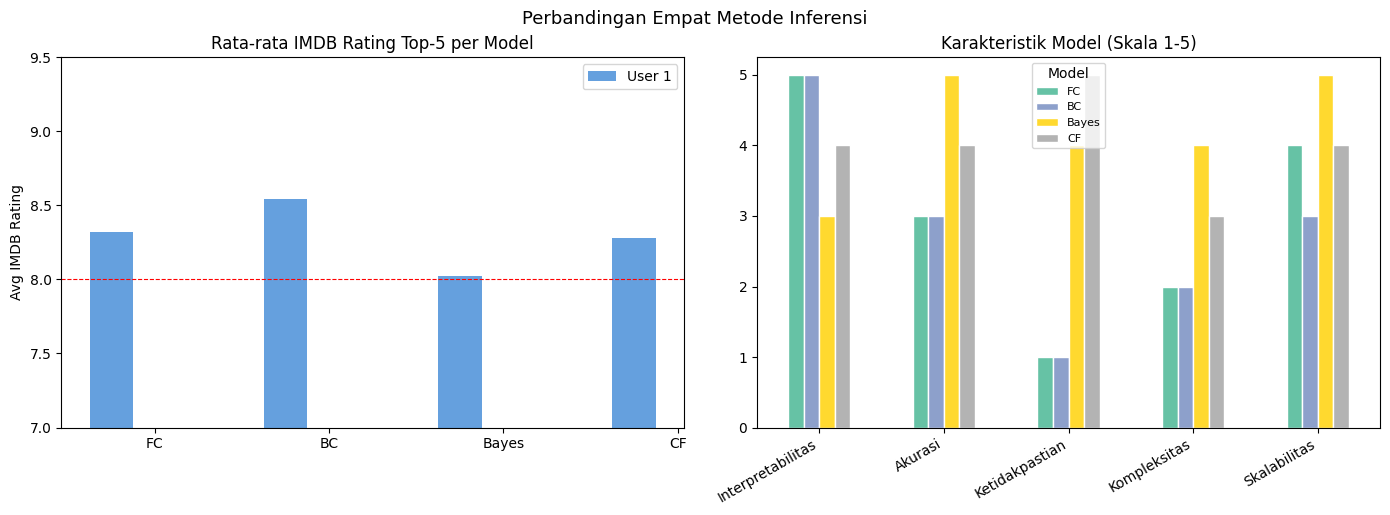

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['FC', 'BC', 'Bayes', 'CF']
cols   = ['FC avg IMDB', 'BC avg IMDB', 'Bayes avg IMDB', 'CF avg IMDB']
x = np.arange(len(models)); w = 0.25
colors = ['#4A90D9', '#E67E22', '#27AE60']

for i, uid in enumerate([1]):
    vals = [summary[summary.User==uid][c].values[0] for c in cols]
    axes[0].bar(x + i*w, vals, w, label=f'User {uid}', color=colors[i], alpha=0.85)
axes[0].set_title('Rata-rata IMDB Rating Top-5 per Model')
axes[0].set_xticks(x + w); axes[0].set_xticklabels(models)
axes[0].set_ylabel('Avg IMDB Rating'); axes[0].set_ylim(7.0, 9.5)
axes[0].legend(); axes[0].axhline(8.0, ls='--', color='red', lw=0.8)

char = pd.DataFrame({
    'Interpretabilitas': [5, 5, 3, 4],
    'Akurasi':           [3, 3, 5, 4],
    'Ketidakpastian':    [1, 1, 4, 5],
    'Kompleksitas':      [2, 2, 4, 3],
    'Skalabilitas':      [4, 3, 5, 4],
}, index=models)
char.T.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Karakteristik Model (Skala 1-5)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend(title='Model', fontsize=8)

plt.tight_layout()
plt.suptitle('Perbandingan Empat Metode Inferensi', fontsize=13, y=1.02)
plt.show()

In [ ]:
print('=== Analisis Overlap Rekomendasi (User 1, top-10) ===')
uid = 1; pref = user_preferences[uid]; prof = {'min_rating': 7.0}
s_fc    = set(fc_model.recommend(uid, pref, prof, 10)['title'])
s_bc    = set(bc_model.recommend(uid, pref, prof, 10)['title'])
s_bayes = set(bayes_model.recommend(uid, pref, user_favorites[uid], 10)['title'])
s_cf    = set(cf_model.recommend(uid, pref, prof, 10)['title'])

pairs = [('FC','BC',s_fc,s_bc), ('FC','Bayes',s_fc,s_bayes),
         ('FC','CF',s_fc,s_cf), ('BC','Bayes',s_bc,s_bayes),
         ('BC','CF',s_bc,s_cf), ('Bayes','CF',s_bayes,s_cf)]
for a, b, sa, sb in pairs:
    print(f'  {a} intersect {b}: {len(sa & sb)} film')
konsensus = s_fc & s_bc & s_bayes & s_cf
print(f'  Konsensus 4 model: {len(konsensus)} film')
if konsensus: print(' ', konsensus)

=== Analisis Overlap Rekomendasi (User 1, top-10) ===
Model Bayes fitted. Top 5 prior genre:
   P(Action) = 0.1667
   P(Drama) = 0.1389
   P(Adventure) = 0.1389
   P(Sci-Fi) = 0.0556
   P(Crime) = 0.0556
  FC intersect BC: 6 film
  FC intersect Bayes: 0 film
  FC intersect CF: 7 film
  BC intersect Bayes: 0 film
  BC intersect CF: 6 film
  Bayes intersect CF: 0 film
  Konsensus 4 model: 0 film


---
## 10. Justifikasi Pemilihan Model Terbaik

In [ ]:
tabel = pd.DataFrame({
    'Metode':           ['Forward Chaining', 'Backward Chaining', 'Teorema Bayes', 'Certainty Factor'],
    'Jenis Reasoning':  ['Data-driven',       'Goal-driven',       'Probabilistik',  'Uncertainty-based'],
    'Ketidakpastian':   ['Tidak',             'Tidak',             'Ya',             'Ya'],
    'Personalisasi':    ['Sedang',            'Sedang',            'Tinggi',         'Sedang'],
    'Self-learning':    ['Tidak',             'Tidak',             'Ya',             'Tidak'],
    'Peran Terbaik':    ['Pre-filter',        'Validasi film',     'ForYou ranking', 'Confidence score'],
})
print(tabel.to_string(index=False))

           Metode   Jenis Reasoning Ketidakpastian Personalisasi Self-learning    Peran Terbaik
 Forward Chaining       Data-driven          Tidak        Sedang         Tidak       Pre-filter
Backward Chaining       Goal-driven          Tidak        Sedang         Tidak    Validasi film
    Teorema Bayes     Probabilistik             Ya        Tinggi            Ya   ForYou ranking
 Certainty Factor Uncertainty-based             Ya        Sedang         Tidak Confidence score


In [ ]:
kesimpulan = '''
KESIMPULAN AKADEMIS
===================
Untuk FITUR FORYOU, Teorema Bayes adalah metode terbaik karena:

1. Memanfaatkan user_favorites sebagai prior probability yang kuat —
   semakin banyak film yang ditandai favorit, semakin akurat prior.

2. Menangani ketidakpastian preferensi secara probabilistik —
   tidak semua pengguna punya preferensi yang tegas.

3. Dapat diperbarui secara inkremental (online learning) —
   setiap interaksi baru memperbaiki rekomendasi.

4. Dukungan akademis kuat: Naive Bayes telah terbukti efektif
   untuk text/item classification (Resnick et al., 1994;
   McCallum & Nigam, 1998).

Kombinasi yang direkomendasikan:
  [1] Forward Chaining  => hard filter (rating minimum)
  [2] Teorema Bayes     => personalized ranking (ForYou)
  [3] Certainty Factor  => tampilkan confidence ke pengguna
'''
print(kesimpulan)


KESIMPULAN AKADEMIS
Untuk FITUR FORYOU, Teorema Bayes adalah metode terbaik karena:

1. Memanfaatkan user_favorites sebagai prior probability yang kuat —
   semakin banyak film yang ditandai favorit, semakin akurat prior.

2. Menangani ketidakpastian preferensi secara probabilistik —
   tidak semua pengguna punya preferensi yang tegas.

3. Dapat diperbarui secara inkremental (online learning) —
   setiap interaksi baru memperbaiki rekomendasi.

4. Dukungan akademis kuat: Naive Bayes telah terbukti efektif
   untuk text/item classification (Resnick et al., 1994;
   McCallum & Nigam, 1998).

Kombinasi yang direkomendasikan:
  [1] Forward Chaining  => hard filter (rating minimum)
  [2] Teorema Bayes     => personalized ranking (ForYou)
  [3] Certainty Factor  => tampilkan confidence ke pengguna



---
## Summary

| Tahap | Status |
|-------|--------|
| Seleksi fitur (8 variabel) | ✅ |
| Cleaning (null, duplikat, tipe data) | ✅ |
| Transformasi (genres_list, era, rating_class, all_stars) | ✅ |
| User persona (profiles, preferences, favorites) | ✅ |
| Forward Chaining | ✅ |
| Backward Chaining | ✅ |
| Teorema Bayes ForYou | ✅ |
| Certainty Factor | ✅ |
| Perbandingan & analisis | ✅ |
| Justifikasi akademis | ✅ |

> **Model terbaik untuk ForYou: Teorema Bayes**  
> *PBL Final Project — Sistem Rekomendasi Film*